In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
#https://huggingface.co/datasets/sunera01/cross-platform-reviews-booking-tripadvisor-gmaps/tree/main

/Users/Kitu/anaconda3/envs/d266myassignment/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Load datase
df = pd.read_csv("cross_platform.csv")

In [8]:
df.columns

Index(['review_text', 'platform', 'rating', 'property_name', 'review_title',
       'date_of_review', 'reviewer_location', 'reviewer_name', 'travelerType'],
      dtype='object')

Class distribution:
 rating_bucket
1.0     3614
2.0     8243
3.0    25343
4.0      685
5.0     2299
Name: count, dtype: int64


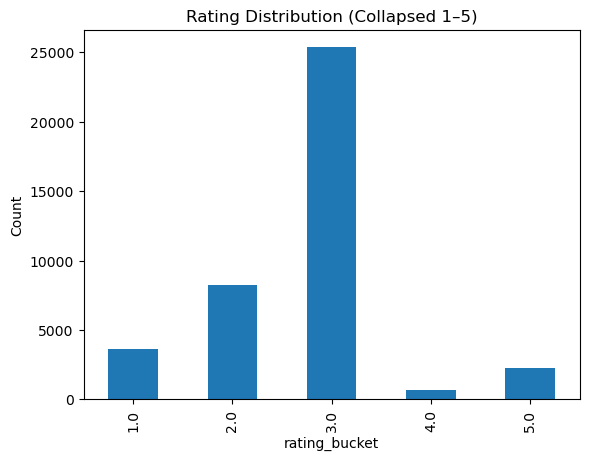


Balanced class distribution:
 rating_bucket
1.0    685
2.0    685
3.0    685
4.0    685
5.0    685
Name: count, dtype: int64


/var/folders/gj/bbgjz4_x5ybc58ms5zv9p8sr0000gp/T/ipykernel_62150/3450889659.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("rating_bucket", group_keys=False).apply(


In [11]:
# Collapse rating 1–10 → 1–5 buckets
def collapse_rating(r):
    if r in [1, 2]:
        return 1
    elif r in [3, 4]:
        return 2
    elif r in [5, 6]:
        return 3
    elif r in [7, 8]:
        return 4
    elif r in [9, 10]:
        return 5


df["rating_bucket"] = df["rating"].apply(collapse_rating)

# Check distribution (imbalance)
rating_counts = df["rating_bucket"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

# visualize the distribution
rating_counts.plot(kind="bar", title="Rating Distribution (Collapsed 1–5)")
plt.xlabel("rating_bucket")
plt.ylabel("Count")
plt.show()

# Balance dataset (undersample the majority class for demonstration)
min_count = rating_counts.min()
balanced_df = df.groupby("rating_bucket", group_keys=False).apply(
    lambda x: x.sample(min_count, random_state=42)
)

print("\nBalanced class distribution:\n", balanced_df["rating_bucket"].value_counts())

Class distribution:
 rating_bucket
1.0    685
2.0    685
3.0    685
4.0    685
5.0    685
Name: count, dtype: int64


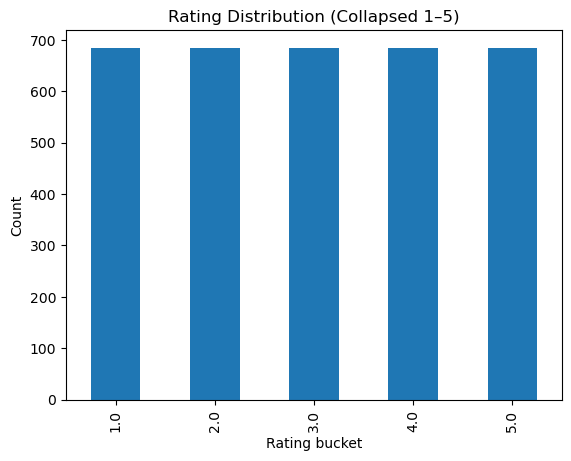

In [15]:
# Revalidate the balanced distribution
# Check distribution (imbalance)
rating_counts = balanced_df["rating_bucket"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

# visualize
rating_counts.plot(kind="bar", title="Rating Distribution (Collapsed 1–5)")
plt.xlabel("Rating bucket")
plt.ylabel("Count")
plt.show()

# This seems to be a good dataset!! 

In [16]:
# save the balanced dataset to you current directory
df.to_csv("crossplatform_tripadvisor_review.csv")

In [8]:
#from transformers import pipeline

#classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

#text = "This drug really helped with my pain but caused nausea."
#candidate_labels = ["very negative", "negative", "neutral", "positive", "very positive"]

#result = classifier(text, candidate_labels)
#print(result)